In [107]:
import pandas as pd

In [109]:
#Task A: Load and inspect data
#Open the notebook, load the CSV, check shape, columns, data types, and missing values.
df = pd.read_csv("marketing_sales_math.csv") 
df.shape
df.columns
print(type(df))
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>


day                    0
promotion_active       0
advertising_spend      0
website_visits         0
price                  0
units_sold             0
revenue                0
cost                   0
profit                 0
customer_rating        0
returns                0
performance_segment    0
dtype: int64

In [118]:
#Task B: Descriptive statistics recap
#Calculate mean, median, mode, range, and standard deviation for selected variables.
# mean, median, standard deviation
print(df[['advertising_spend','website_visits','profit']].agg(['mean', 'median', 'std']))

# mode
print("Mode of performance segment:", df['performance_segment'].mode()[0])

# Range
print("Range of profit:",df['profit'].max()-df['profit'].min())

        advertising_spend  website_visits       profit
mean           281.059167     2203.683333  1372.319417
median         286.780000     2128.000000  1282.330000
std             57.841820      399.997941   515.511476
Mode of performance segment: Medium profit
Range of profit: 2336.1800000000003


In [121]:
#Task C: Linear algebra view
# Represent one row as a vector and select numerical columns as a matrix.

# Representing one row as a Vector
vector_day1=df.loc[0,['advertising_spend','website_visits','price','units_sold','revenue']].values
print(vector_day1)

# Representing selected numerical columns as a Matrix
matrix= df[['advertising_spend','website_visits','price','units_sold','revenue']].values
print(matrix)

# Shape of the matrix
matrix.shape  

# Display a scaler
scaler_advertising_spend_day1= df.loc[0, 'advertising_spend']
print('Advertising Spend on Day 1:',scaler_advertising_spend_day1)

[np.float64(283.92) np.int64(2069) np.float64(38.76) np.int64(86)
 np.float64(3333.36)]
[[ 283.92 2069.     38.76   86.   3333.36]
 [ 257.53 1999.     40.12   66.   2647.92]
 [ 304.75 2306.     38.28   83.   3177.24]
 [ 292.01 2280.     39.03  101.   3942.03]
 [ 289.2  2099.     39.51   80.   3160.8 ]
 [ 313.13 2306.     38.34   91.   3488.94]
 [ 311.97 2297.     39.22   82.   3216.04]
 [ 306.47 2262.     39.09   74.   2892.66]
 [ 295.83 2420.     39.32  103.   4049.96]
 [ 310.01 2386.     38.39  113.   4338.07]
 [ 282.07 2107.     39.46   88.   3472.48]
 [ 303.7  2411.     40.14  111.   4455.54]
 [ 304.6  2525.     41.39  104.   4304.56]
 [ 285.44 2339.     40.91   78.   3190.98]
 [ 272.78 2061.     42.43  109.   4624.87]
 [ 323.45 2418.     39.02  104.   4058.08]
 [ 286.91 2381.     41.07   86.   3532.02]
 [ 315.35 2365.     40.32   98.   3951.36]
 [ 305.46 2414.     42.8    91.   3894.8 ]
 [ 269.82 2260.     39.27   78.   3063.06]
 [ 336.59 2464.     39.29  105.   4125.45]
 [ 316.09

In [123]:
#Task D: Weighted score
#Use a dot product to create a simple business score from standardized variables.

# Selected Variables
features = ['advertising_spend',
            'website_visits',
            'units_sold',
            'revenue']

# Standardise the data
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_scaled=scaler. fit_transform (df[features]) # Now every column has: mean≈ 0, std ≈ 1

# Assigned weights based on business importance
weights= [0.2,0.2,0.3,0.3] # Meaning: advertising_spend = 20%,website_visits = 20%,units_sold = 30%,revenue = 30%
#Weights should add up to 1

#calculated business score
import numpy as np
business_score=np.dot(x_scaled,weights)
# Add the business_score to the DataFrame as a new column
df['business_score'] = business_score
df[['business_score']].head()

,business_score
0,-0.129101
1,-0.718476
2,-0.024928
3,0.383396
4,-0.223464


In [125]:
# Task E: Change and derivatives
# Use .diff() to calculate daily change in revenue and profit.
#The .diff() function was used to calculate the day-to-day change in revenue and profit. It computes the difference between the current day's value and the previous day's value. 
# Positive values indicate an increase, while negative values indicate a decrease.
#This concept is related to derivatives in calculus because both measure the rate of change.

# #calculated the day to day change in revenue 
df['revenue_change']= df['revenue'].diff()
print(df[['revenue','revenue_change']].head())

# Day-to-day change in profit
df['profit_change']= df['profit'].diff()
print(df[['profit','profit_change']].head(6))

# To find the strongest increase and the strongest decrease in revenue
best_revenue_day= df.loc[df['revenue_change'].idxmax()]
print("Largest revenue increase:")
print(best_revenue_day[['day','revenue','revenue_change']])

worst_revenue_day= df.loc[df['revenue_change'].idxmin()]
print("Largest revenue decrease:")
print(worst_revenue_day[['day','revenue','revenue_change']])

   revenue  revenue_change
0  3333.36             NaN
1  2647.92         -685.44
2  3177.24          529.32
3  3942.03          764.79
4  3160.80         -781.23
    profit  profit_change
0  1375.43            NaN
1  1165.13        -210.30
2  1402.59         237.46
3  1686.22         283.63
4  1313.51        -372.71
5  1485.29         171.78
Largest revenue increase:
day                   113
revenue           4276.09
revenue_change    1749.61
Name: 112, dtype: object
Largest revenue decrease:
day                    30
revenue            3383.0
revenue_change   -2018.32
Name: 29, dtype: object


In [126]:
# Task F: Functions and transformations
# Use log transformation for website visits and interpret why it is useful.

df['log_webiste_visits']= np.log(df['website_visits'])
df[['website_visits','log_webiste_visits']].head()

,website_visits,log_webiste_visits
0,2069,7.634821
1,1999,7.600402
2,2306,7.743270
3,2280,7.731931
4,2099,7.649216


In [129]:
#Task G: Integration as accumulation
# Use cumulative sum to calculate cumulative revenue and cumulative profit.

df['cumulative_revenue'] = df['revenue'].cumsum()
df['cumulative_profit'] = df['profit'].cumsum()
df[['revenue',
    'cumulative_revenue',
    'profit',
    'cumulative_profit']].head()

,revenue,cumulative_revenue,profit,cumulative_profit
0,3333.36,3333.36,1375.43,1375.43
1,2647.92,5981.28,1165.13,2540.56
2,3177.24,9158.52,1402.59,3943.15
3,3942.03,13100.55,1686.22,5629.37
4,3160.80,16261.35,1313.51,6942.88


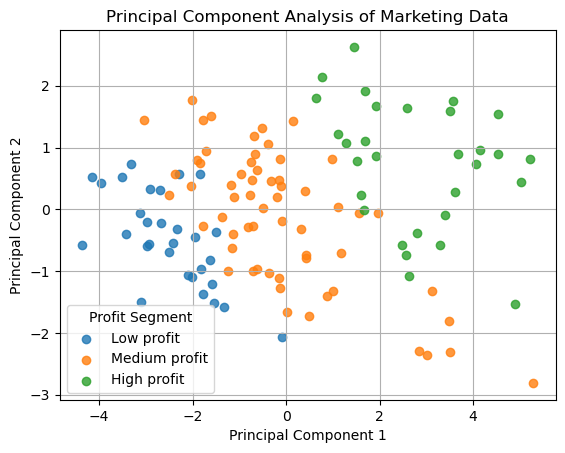

[0.77829688 0.16708756]
Explained variance ratio:
PC1: 0.778
PC2: 0.167
Total: 0.945


In [130]:
#Task H: PCA
#Standardize numerical features, apply PCA, visualize PC1 and PC2, and interpret explained variance.

# Select numerical features
features = ['advertising_spend','website_visits','price','units_sold','revenue', 'cost', 'profit']
X = df[features]

# Standardize the Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)  # This creates: PC1 (Principal Component 1),PC2 (Principal Component 2)

#Create a New DataFrame
pca_df= pd.DataFrame(principal_components,columns=['PC1','PC2'])
pca_df.head()

# Add PC1 and PC2 to original DataFrame
df['PC1'] = pca_df['PC1']
df['PC2'] = pca_df['PC2']

#Visualize PCA result
import matplotlib.pyplot as plt

for segment in ['Low profit', 'Medium profit', 'High profit']:
    subset = df[df['performance_segment']== segment]
    plt.scatter(subset['PC1'],subset['PC2'], label = segment, alpha=0.8,)
    
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Principal Component Analysis of Marketing Data')
plt.legend(title='Profit Segment')
plt.grid(True)
plt.show()  

# Explained Variance
print(pca.explained_variance_ratio_)
print("Explained variance ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 3))
print("PC2:", round(pca.explained_variance_ratio_[1], 3))
print("Total:", round(pca.explained_variance_ratio_.sum(), 3))

In [98]:
# # PCA loadings: which original features contribute to each component?
loadings = pd.DataFrame(pca.components_.T, columns=['PC1_loading','PC2_loading'],index=features)
loadings

,PC1_loading,PC2_loading
advertising_spend,0.385552,-0.170272
website_visits,0.410464,-0.055687
price,-0.121175,0.874358
units_sold,0.423356,-0.038833
revenue,0.414784,0.200511
cost,0.416364,-0.055622
profit,0.378881,0.398245
